## Setup
We import all required libraries and define the downsample factor. 
To manage memory efficiently with large national-scale rasters, all 
rasters are downsampled to 250m resolution (factor of 10) from the 
original 25m, reducing memory usage by 100x while preserving spatial 
patterns at national scale.

In [4]:
# ============================================================
# SETUP: Import tools and configure settings
# ============================================================
# We import specialised Python libraries — think of them as
# toolboxes that give us ready-made functions for mapping,
# raster analysis, maths and plotting.

import geopandas as gpd          # For reading/writing geographic vector files (polygons, lines, points)
import rasterio                   # For reading/writing raster (pixel grid) files like .tif maps
import numpy as np                # For fast numerical operations on large arrays of numbers
import matplotlib.pyplot as plt   # For drawing charts and maps
import matplotlib.patches as mpatches  # For creating custom legend symbols
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap  # For building smooth colour ramps
from rasterio.plot import show    # Convenience function to display a raster on a map axes
from rasterio.warp import reproject, Resampling  # For reprojecting rasters to a different CRS
from rasterio.mask import mask as rasterio_mask  # For clipping a raster to a polygon boundary
from rasterio.features import rasterize  # For converting vector shapes into pixel grids
from shapely.geometry import mapping, box  # Geometry utilities (bounding box, GeoJSON conversion)
import pandas as pd               # For working with tables (DataFrames)
import os                         # For file path operations
import gc                         # For freeing unused memory (garbage collection)

# ── Downsampling factor ────────────────────────────────────
# The original hazard rasters have 25-metre pixel resolution.
# At national scale that produces enormous arrays (millions of
# pixels) that would exhaust RAM.  We read every 10th pixel in
# each direction (FACTOR = 10), resulting in 250 m resolution.
# This reduces memory usage by 10 × 10 = 100x while preserving
# the spatial patterns that matter at the national scale.
FACTOR = 10

print("Libraries loaded successfully!")


Libraries loaded successfully!


## 1. Load Data
### 1.1 Load Portugal Boundary

In [5]:
# ── Load the world countries shapefile and keep only Portugal ──
# gpd.read_file() reads a shapefile (.shp) into a GeoDataFrame —
# essentially a table where every row is a geographic feature with
# a geometry (shape) column.
# .to_crs("EPSG:3763") reprojects the data to the official
# Portuguese coordinate system (PT-TM06 / ETRS89), so distances
# and areas will be in metres.
world = gpd.read_file("../data/raw/portugal_boundaries/ne_10m_admin_0_countries_prt.shp").to_crs("EPSG:3763")

# Filter to keep only the row where the country name is "Portugal"
portugal = world[world["ADMIN"] == "Portugal"]

# Define a bounding box that covers only mainland Portugal, excluding
# the Azores and Madeira island groups.  Coordinates are in metres
# in the Portuguese national grid (EPSG:3763).
mainland_bbox = box(-150000, -350000, 150000, 350000)

# Clip the Portugal polygon to the mainland bounding box
portugal_mainland = portugal.clip(mainland_bbox)

print("Portugal boundary loaded:", portugal_mainland.shape)


Portugal boundary loaded: (1, 169)


### 1.2 Load Vector Datasets
We load all vector layers needed for the risk model: burned area perimeters 
for each year, critical fire locations, vegetation index, aridity index 
and the primary fuel management network.

In [6]:
# ── Burned area perimeters (one shapefile per year) ─────────
# Each file contains the boundaries of fires that occurred that year.
# We load all four years separately so we can colour them differently
# on maps and analyse annual trends.
burned_2021 = gpd.read_file("../data/raw/burned_areas/burned_2021/ardida_2021.shp")
burned_2022 = gpd.read_file("../data/raw/burned_areas/burned_2022/ardida_2022.shp")
burned_2023 = gpd.read_file("../data/raw/burned_areas/burned_2023/ardida_2023.shp")
burned_2024 = gpd.read_file("../data/raw/burned_areas/burned_2024/ardida_2024.shp")

# ── Other risk-factor vector layers ──────────────────────────
# critical_locations : areas structurally prone to fire
#   (high fuel load, difficult access, poor management history)
# vegetation         : polygons with a vegetation density index (iqv)
#   — denser vegetation = more fuel available for fires
# aridity            : polygons with an aridity class
#   — drier areas = fuel desiccates faster and ignites more easily
# fuel_network       : lines representing the primary fuel management
#   network (fire breaks, cleared corridors) built by ICNF to slow
#   fire spread across the territory
critical_locations = gpd.read_file("../data/raw/critical_fire_locations/critical_location.shp")
vegetation         = gpd.read_file("../data/raw/vegetation_index/iqv_2000.shp")
aridity            = gpd.read_file("../data/raw/aridity_index/aridity_index_2000_2010.shp")
fuel_network       = gpd.read_file("../data/raw/primary_fuel_management_network/primary_network.shp")

print("Burned areas 2021:", burned_2021.shape)
print("Burned areas 2022:", burned_2022.shape)
print("Burned areas 2023:", burned_2023.shape)
print("Burned areas 2024:", burned_2024.shape)
print("Critical locations:", critical_locations.shape)
print("Vegetation:", vegetation.shape)
print("Aridity:", aridity.shape)
print("Fuel network:", fuel_network.shape)


Burned areas 2021: (918, 23)
Burned areas 2022: (1786, 24)
Burned areas 2023: (1736, 24)
Burned areas 2024: (1558, 23)
Critical locations: (8265, 23)
Vegetation: (6, 4)
Aridity: (674, 4)
Fuel network: (5529, 11)


### 1.3 Load Hazard Rasters
We load each annual hazard raster at 250m resolution immediately to save memory.

In [7]:
# ── Dictionary mapping each year to its hazard raster file path ─
# "Conjunctural hazard" is an annual composite map produced by ICNF
# that combines weather conditions, drought indices and vegetation
# state to reflect the current-season fire danger for that year.
hazard_paths = {
    2021: "../data/raw/conjunctural_hazard_maps/conjunctural_hazard_2021/perigosidade_conjuntural_2021.tif",
    2022: "../data/raw/conjunctural_hazard_maps/conjunctural_hazard_2022/perigosidade_conjuntural_2022.tif",
    2023: "../data/raw/conjunctural_hazard_maps/conjunctural_hazard_2023/perigosidade_conjuntural2023.tif",
    2024: "../data/raw/conjunctural_hazard_maps/conjunctural_hazard_2024/PerigosidadeConjuntural_2024/perigosidade_conjuntural2024.tif",
}

# ── Nodata values differ between datasets ───────────────────
# Each raster uses a sentinel number to mean "no data here"
# (e.g. outside Portugal, or missing).  We must mask these out
# before doing any arithmetic so they don't corrupt the averages.
# 2021 uses 255 (typical for 8-bit unsigned data).
# 2022 has no explicit nodata flag (None = rely on value == 0).
# 2023 and 2024 use 15 (their maximum valid class value is 14).
nodata_values = {2021: 255, 2022: None, 2023: 15, 2024: 15}

# ── Build the common reference grid at 250 m resolution ─────
# All rasters and vector-to-raster conversions must share the
# same grid (same pixel size, same origin, same CRS) so that
# we can overlay them in a single NumPy array operation later.
# We derive this grid from the 2021 raster, dividing its width
# and height by FACTOR (10) to get 250 m pixels instead of 25 m.
with rasterio.open(hazard_paths[2021]) as ref:
    ref_height = ref.height // FACTOR   # number of pixel rows at 250 m
    ref_width  = ref.width  // FACTOR   # number of pixel columns at 250 m
    # rasterio Affine transforms encode the top-left corner, pixel
    # width and pixel height.  Scaling by (original / new) dimensions
    # gives the correct transform for our downsampled grid.
    ref_transform = ref.transform * ref.transform.scale(
        ref.width  / ref_width,
        ref.height / ref_height
    )
    ref_crs   = ref.crs            # coordinate reference system (EPSG:3763)
    ref_shape = (ref_height, ref_width)  # (rows, cols) tuple used throughout

print("Reference grid shape:", ref_shape)
print("Reference CRS:", ref_crs)


Reference grid shape: (2306, 1125)
Reference CRS: EPSG:3763


### 1.2 Create Portugal Mainland Mask
We create a raster mask of mainland Portugal to clip all raster 
visualisations to the country boundary.

In [8]:
from rasterio.features import geometry_mask
from shapely.geometry import mapping

# Convert the Portugal mainland polygon to GeoJSON-like dictionaries
# that rasterio's geometry_mask function can understand.
portugal_geom = [mapping(geom) for geom in portugal_mainland.geometry]

# geometry_mask() burns the polygon into a boolean array the same
# size as our reference grid.  By default it marks pixels *outside*
# the polygon as True; setting invert=True flips this so that pixels
# *inside* Portugal are True (=1) and outside are False (=0).
# We use this mask later to blank out ocean / island pixels on maps.
port_mask = geometry_mask(
    portugal_geom,
    out_shape=ref_shape,
    transform=ref_transform,
    invert=True   # True = inside Portugal (the area we care about)
)

print("Portugal mask created:", port_mask.shape)
print("Pixels inside Portugal:", port_mask.sum())


Portugal mask created: (2306, 1125)
Pixels inside Portugal: 1414222


## 2. Data Preparation
### 2.1 Merge Burned Areas and Prepare Vector Layers
We merge the four annual burned area layers into a single cumulative 
layer and convert categorical variables to numerical values for 
use in the risk model.

In [9]:
# ── Merge all four annual burned-area layers into one table ──
# We only need the geometry (the polygon shapes) for the risk model,
# so we drop all other attribute columns.  pd.concat() stacks the
# four GeoDataFrames vertically, and reset_index() gives the combined
# table a clean sequential index (0, 1, 2, ...).
cols = ["geometry"]
burned_all = pd.concat([
    burned_2021[cols], burned_2022[cols],
    burned_2023[cols], burned_2024[cols]
]).reset_index(drop=True)

print("Total fire perimeters:", len(burned_all))

# ── Convert text categories to numbers ───────────────────────
# The vegetation and aridity datasets store risk levels as human-
# readable text (e.g. "Alta", "Semiarido").  NumPy cannot do maths
# on text, so we map each category to an integer.  The order
# reflects increasing fire risk — higher number = higher risk.

# Vegetation index (iqv): how dense/abundant the fuel is
# 1 = sparse (Baixa), 5 = very dense (Muito alta)
vegetation_map = {
    'NoData': np.nan,   # unknown — treated as missing
    'Baixa': 1,         # Low vegetation density
    'Media': 2,         # Medium
    'Moderada': 3,      # Moderate
    'Alta': 4,          # High
    'Muito alta': 5     # Very High
}

# Aridity index: how dry the climate is
# 1 = humid (fires less likely to spread), 4 = semi-arid (high risk)
aridity_map = {
    'Humido': 1,           # Humid
    'Subhumido Humido': 2, # Sub-humid (wet side)
    'Subhumido Seco': 3,   # Sub-humid (dry side)
    'Semiarido': 4         # Semi-arid — highest desiccation risk
}

# .map() replaces each text value in the column with its number
vegetation["iqv_num"]   = vegetation["iqv"].map(vegetation_map)
aridity["indaride_num"] = aridity["indaride"].map(aridity_map)

print("Vegetation values:", vegetation["iqv_num"].unique())
print("Aridity values:",    aridity["indaride_num"].unique())


Total fire perimeters: 5998
Vegetation values: [nan  3.  4.  5.  1.]
Aridity values: [nan  2.  1.  3.  4.]


### 2.2 Load and Normalise Hazard Rasters
We load each annual hazard raster at 250m resolution and normalise 
them to a 0-1 scale before averaging. Normalisation is necessary 
because the four years use different original scales (0-255, 0-5, 0-15), 
which would bias the average if used directly.

In [10]:
# ── Load and normalise each annual hazard raster ─────────────
# We iterate over the four years, loading each raster at 250 m
# resolution and normalising its values to a 0-1 scale.
#
# WHY NORMALISE?
# The four datasets were produced in different years and may use
# different value ranges (e.g. 2021 uses 0-255, 2023/2024 use 0-15).
# If we averaged the raw numbers, the 0-255 dataset would dominate.
# Normalising to 0-1 puts all years on equal footing before averaging.

hazard_arrays = []

for year, path in hazard_paths.items():
    with rasterio.open(path) as src:
        # out_shape tells rasterio to return the data already resampled
        # to our 250 m reference grid — avoids loading the full 25 m array.
        data = src.read(1, out_shape=ref_shape).astype("float32")

        # Mask nodata sentinel values -> NaN (Not a Number = missing)
        nd = nodata_values[year]
        if nd is not None:
            data[data == nd] = np.nan

        # Also treat zeros as missing (pixels with no hazard information)
        data[data == 0] = np.nan

        # Min-max normalisation: (value - min) / (max - min)
        # Result: minimum -> 0.0, maximum -> 1.0, everything else in between.
        data_min = np.nanmin(data)   # nanmin ignores NaN cells
        data_max = np.nanmax(data)
        data = (data - data_min) / (data_max - data_min)

        hazard_arrays.append(data)

# Stack the four 2-D arrays into a 3-D cube (4 x rows x cols) and
# take the mean along axis 0 (the year axis).
# np.nanmean ignores NaN — if a pixel is missing in one year,
# the average is computed from the remaining years rather than
# becoming NaN entirely.
hazard_mean = np.nanmean(np.stack(hazard_arrays, axis=0), axis=0)

print("Hazard mean shape:", hazard_mean.shape)
print("Hazard mean range:", np.nanmin(hazard_mean), "-", np.nanmax(hazard_mean))


Hazard mean shape: (2306, 1125)
Hazard mean range: 0.0 - 1.0


C:\Users\ritap\AppData\Local\Temp\ipykernel_30352\458947244.py:40: RuntimeWarning: Mean of empty slice
  hazard_mean = np.nanmean(np.stack(hazard_arrays, axis=0), axis=0)


### 2.3 Rasterise Vector Layers
We convert all vector layers to raster format at 250m resolution 
using the hazard layer as the reference grid.

In [11]:
# ── Rasterise all vector layers to the 250 m reference grid ──
# "Rasterisation" converts polygon/point/line shapes into a pixel
# grid.  Each pixel gets the value of the feature that covers it.
# We need this step because the risk model is computed pixel-by-pixel
# and all inputs must be in the same grid format.

portugal_geom = [mapping(geom) for geom in portugal_mainland.geometry]

# ── Burned areas -> binary raster (1 = burned 2021-2024, 0 = not) ──
# We don't need a count of how many times each pixel burned — just
# whether it has burned at all.  Burned pixels get value 1; all
# others default to 0 (fill=0).
burned_geoms = [(geom, 1) for geom in burned_all.geometry if geom is not None]
burned_raster = rasterize(
    burned_geoms, out_shape=ref_shape,
    transform=ref_transform, fill=0, dtype="float32"
)

# ── Critical locations -> value = NivelCriti (criticality level) ──
# NivelCriti is a numeric field indicating how structurally fire-prone
# the location is.  Higher values mean more chronic risk.
critical_geoms = [(geom, val) for geom, val in
                  zip(critical_locations.geometry, critical_locations["NivelCriti"])
                  if geom is not None]
critical_raster = rasterize(
    critical_geoms, out_shape=ref_shape,
    transform=ref_transform, fill=0, dtype="float32"
)

# ── Vegetation -> value = iqv_num (1-5, fuel availability) ──
# We skip any feature whose numeric value is NaN (was "NoData" in the source).
veg_geoms = [(geom, val) for geom, val in
             zip(vegetation.geometry, vegetation["iqv_num"])
             if geom is not None and not np.isnan(val)]
veg_raster = rasterize(
    veg_geoms, out_shape=ref_shape,
    transform=ref_transform, fill=0, dtype="float32"
)

# ── Aridity -> value = indaride_num (1-4, dryness level) ──
arid_geoms = [(geom, val) for geom, val in
              zip(aridity.geometry, aridity["indaride_num"])
              if geom is not None and not np.isnan(val)]
arid_raster = rasterize(
    arid_geoms, out_shape=ref_shape,
    transform=ref_transform, fill=0, dtype="float32"
)

print("Burned range:",    burned_raster.min(),   "-", burned_raster.max())
print("Critical range:",  critical_raster.min(), "-", critical_raster.max())
print("Vegetation range:", veg_raster.min(),     "-", veg_raster.max())
print("Aridity range:",   arid_raster.min(),     "-", arid_raster.max())


Burned range: 0.0 - 1.0
Critical range: 0.0 - 25.9366
Vegetation range: 0.0 - 5.0
Aridity range: 0.0 - 4.0


### 2.4 Normalise to 1–5 Scale and Apply Weighted Overlay
We normalise all layers to a common 1–5 scale and combine them using 
the weighted formula. Zeros are treated as nodata and excluded from 
the calculation. The weight sum is tracked per pixel so that missing 
layers do not bias the result.

**Risk = 0.35 × Conjunctural Hazard + 0.20 × Critical Locations + 0.20 × Burned Areas + 0.15 × Vegetation + 0.10 × Aridity**

In [12]:
# ── Helper function: rescale any layer to the 1-5 risk scale ──
def normalise_1_5(arr, binary=False):
    """
    Rescale a raster array to a 1-5 ordinal scale.

    Parameters
    ----------
    arr    : NumPy array -- the input layer (already rasterised).
    binary : bool -- if True, treat the array as a presence/absence
             layer where 1 = present (assigned risk 5) and
             0 = absent (assigned risk 1).  Used for burned areas.

    Returns
    -------
    out : NumPy array of float32 with values in [1, 5] where data
          exists, and NaN where there is no data.

    WHY 1-5?
    All five input layers use different natural scales (0-1, 0-15,
    1-4, 1-5, binary 0/1).  Rescaling everything to a common 1-5
    ordinal means that the weighted average is fair -- no single layer
    dominates just because its raw numbers are larger.
    """
    out = np.full(arr.shape, np.nan, dtype="float32")  # start with all NaN

    if binary:
        # Burned = highest risk (5); unburned = lowest risk (1)
        out[arr == 1] = 5
        out[arr == 0] = 1
    else:
        mask = arr > 0   # pixels with actual data (0 was our fill/nodata value)
        if mask.sum() > 0:
            mn, mx = arr[mask].min(), arr[mask].max()
            if mx > mn:
                # Linear stretch: 1 + (value - min) / (max - min) * 4
                # -> minimum value maps to 1, maximum to 5
                out[mask] = 1 + (arr[mask] - mn) / (mx - mn) * 4
            else:
                out[mask] = 1  # all values identical -> assign bottom of scale
        out[~mask] = np.nan  # pixels that were 0 become NaN (no data)
    return out


# ── Normalise each layer to the 1-5 scale ───────────────────
# hazard_mean is already 0-1 from the earlier step; we stretch it
# to 1-5 directly rather than calling the helper function.
hazard_1_5   = np.where(hazard_mean > 0, 1 + hazard_mean * 4, np.nan).astype("float32")
burned_1_5   = normalise_1_5(burned_raster, binary=True)  # presence/absence
critical_1_5 = normalise_1_5(critical_raster)
veg_1_5      = normalise_1_5(veg_raster)
arid_1_5     = normalise_1_5(arid_raster)

# Free the raw rasters from memory -- we no longer need them and RAM
# is limited when working with national-scale arrays.
del burned_raster, critical_raster, veg_raster, arid_raster
gc.collect()  # force Python's garbage collector to release the freed memory

# ── Weighted overlay formula ─────────────────────────────────
# Risk = 0.35 x Hazard + 0.20 x Critical locations
#       + 0.20 x Burned areas + 0.15 x Vegetation + 0.10 x Aridity
#
# The weights reflect the relative importance of each factor.
# Conjunctural hazard receives the highest weight (35%) because it
# integrates weather, drought and fuel moisture into a single annual
# danger score.  Burned areas and critical locations each receive 20%
# because recent burning predicts future risk and structural
# vulnerability is a persistent driver.  Vegetation (15%) and aridity
# (10%) are background factors that change slowly over time.
# The weights sum to 1.00 (100%).

weights = {"hazard": 0.35, "critical": 0.20, "burned": 0.20, "veg": 0.15, "arid": 0.10}
layers  = {"hazard": hazard_1_5, "critical": critical_1_5,
           "burned": burned_1_5, "veg": veg_1_5, "arid": arid_1_5}

# Accumulate the weighted sum pixel by pixel.
# We also track the total weight of non-NaN layers per pixel so that
# if one layer is missing in a location, the weights of the remaining
# layers are rescaled to still sum to 1 -- rather than leaving that
# pixel with an artificially deflated score.
risk_model  = np.zeros(ref_shape, dtype="float32")
weight_sum  = np.zeros(ref_shape, dtype="float32")

for name, layer in layers.items():
    w    = weights[name]
    mask = ~np.isnan(layer)      # True where this layer has valid data
    risk_model[mask] += layer[mask] * w   # add weighted contribution
    weight_sum[mask] += w                 # accumulate weight for this pixel

# Divide by the actual weight sum (<=1 if some layers were missing)
# to get a properly normalised risk score in the 1-5 range.
# Pixels where no layer had data remain NaN.
risk_model = np.where(weight_sum > 0, risk_model / weight_sum, np.nan)

print("Risk model range:", np.nanmin(risk_model), "-", np.nanmax(risk_model))
print("Risk model shape:", risk_model.shape)


Risk model range: 1.0 - 5.0
Risk model shape: (2306, 1125)


### 2.5. Load Municipality Boundaries
We load the official municipality boundaries for mainland Portugal. 
This layer is essential for the municipal-level analysis — it allows 
us to calculate coverage gaps and vulnerability scores per municipality 
and identify which territories are most at risk and least protected.

In [13]:
# ── Load official municipality (concelho) boundaries ─────────
# Portugal has 308 municipalities on the mainland.  We use this
# layer to aggregate the raster risk scores to the administrative
# unit level, enabling comparisons between local governments.
municipalities = gpd.read_file("../data/raw/municipalities/concelhos_Project.shp")

print(municipalities.shape)            # (n_municipalities, n_columns)
print(municipalities.crs)              # should match EPSG:3763
print(municipalities.columns.tolist()) # inspect available attribute fields
print(municipalities.head())           # preview the first few rows


(281, 3)
EPSG:3763
['ObjectID', 'NAME', 'geometry']
   ObjectID           NAME                                           geometry
0        94        Setúbal  POLYGON ((-77793.528 -120594.573, -77605.067 -...
1        95  Vila Do Bispo  POLYGON ((-56876.481 -288057.984, -56957.02 -2...
2        96       Sesimbra  POLYGON ((-78862.629 -120548.788, -78716.522 -...
3       104          Moura  POLYGON ((86129.19 -167278.897, 86122.452 -167...
4       105         Tavira  POLYGON ((44589.473 -264189.183, 45191.197 -26...


## 3. Exploratory Analysis
### 3.1 Cumulative Burned Areas Map
We plot all burned area perimeters for the study period (2021–2024), 
with each year shown in a different colour to highlight temporal patterns.

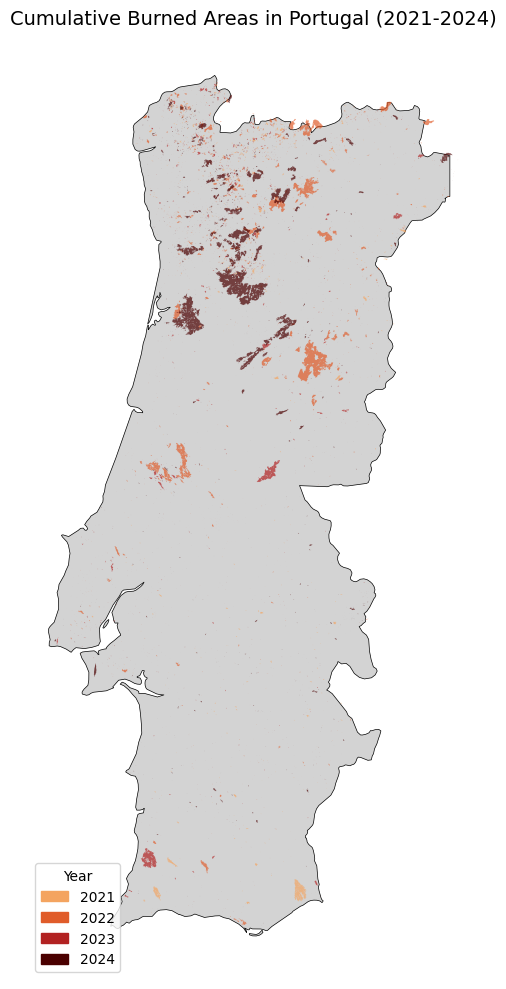

In [14]:
import matplotlib.patches as mpatches

# ── Tag each burned-area record with its year ────────────────
# We add a "year" column before merging so that the plot can
# colour each fire perimeter according to when it occurred.
burned_2021["year"] = 2021
burned_2022["year"] = 2022
burned_2023["year"] = 2023
burned_2024["year"] = 2024

# Combine all four years into one GeoDataFrame for plotting
cols = ["year", "geometry"]
burned_all_plot = pd.concat([
    burned_2021[cols], burned_2022[cols],
    burned_2023[cols], burned_2024[cols]
]).reset_index(drop=True)

# ── Colour scheme: earlier years = lighter orange; 2024 = dark red ──
# The progression from light to dark implies increasing intensity
# and makes it visually easy to identify the most recent fires.
colors = {2021: "#f4a460", 2022: "#e05c2a", 2023: "#b22222", 2024: "#4a0000"}

# ── Draw the map ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 10))  # tall portrait format suits Portugal

# Base layer: Portugal mainland boundary in light grey
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)

# Draw fire perimeters year by year on top of the base map
for year, color in colors.items():
    burned_all_plot[burned_all_plot["year"] == year].plot(
        ax=ax, color=color, edgecolor="none", alpha=0.7
    )

# Build a manual legend (one coloured rectangle per year)
patches = [mpatches.Patch(color=c, label=str(y)) for y, c in colors.items()]
ax.legend(handles=patches, title="Year", loc="lower left")

ax.set_title("Cumulative Burned Areas in Portugal (2021-2024)", fontsize=14)
ax.set_axis_off()   # hide the coordinate axis ticks -- cleaner for a map
plt.tight_layout()
plt.savefig("../outputs/burned_areas_2021_2024.png", dpi=150)
plt.show()


### 3.2 Total Burned Area per Year
We calculate and visualise the total burned area in hectares for each 
year to highlight which years were most destructive.

   year  total_area_ha
0  2021   27374.628894
1  2022  115148.600723
2  2023   34151.106022
3  2024  139396.848847


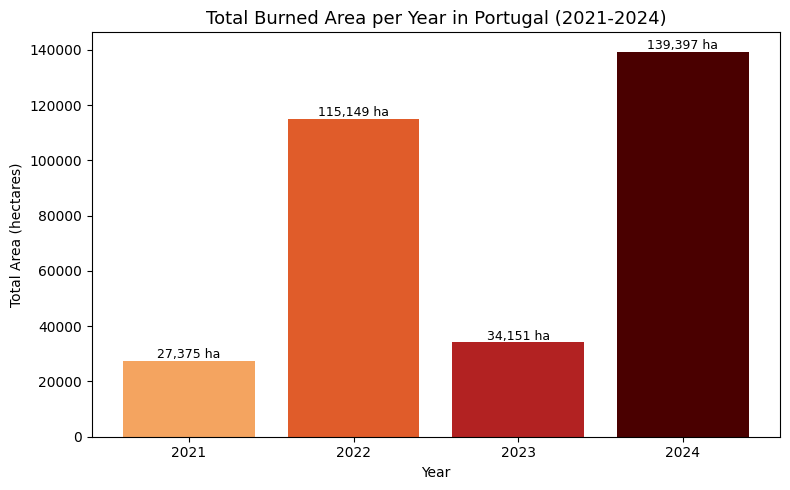

In [15]:
# ── Calculate area in hectares for each fire perimeter ───────
# .geometry.area returns the area in the native CRS units (metres
# squared, because we are in EPSG:3763).  Dividing by 10,000
# converts to hectares (1 ha = 10,000 m2), the conventional unit
# used for reporting burned area statistics.
burned_all_plot["area_ha"] = burned_all_plot.geometry.area / 10000

# Aggregate: sum all fire perimeter areas per year
summary = burned_all_plot.groupby("year")["area_ha"].sum().reset_index()
summary.columns = ["year", "total_area_ha"]

print(summary)

# ── Bar chart: total burned area by year ─────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(summary["year"], summary["total_area_ha"],
       color=["#f4a460", "#e05c2a", "#b22222", "#4a0000"])
ax.set_title("Total Burned Area per Year in Portugal (2021-2024)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Total Area (hectares)")
ax.set_xticks([2021, 2022, 2023, 2024])

# Annotate each bar with the exact value so readers don't have to
# estimate heights from the y-axis.  "+ 1000" shifts the label
# slightly above the bar top to avoid overlapping the bar edge.
for i, row in summary.iterrows():
    ax.text(row["year"], row["total_area_ha"] + 1000,
            f"{row['total_area_ha']:,.0f} ha", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/burned_area_per_year.png", dpi=150)
plt.show()


### 3.3 Burned Areas by Year
We plot each year separately to visualise how the spatial distribution 
of fires shifted across the study period.

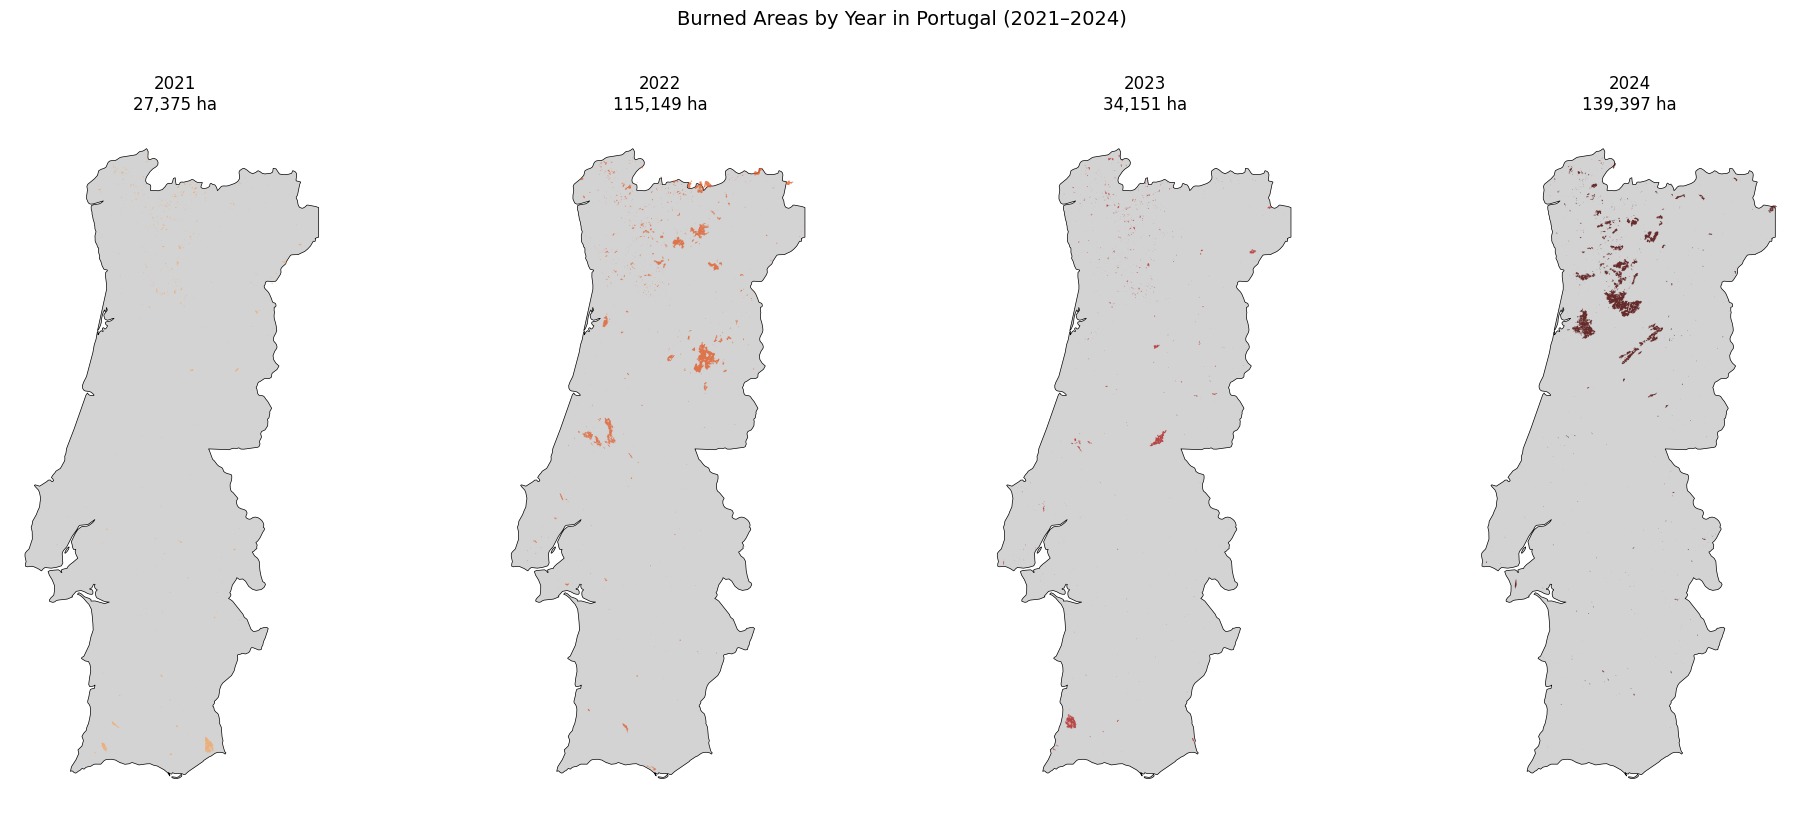

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 8))

for ax, (year, color) in zip(axes, colors.items()):
    portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
    burned_all_plot[burned_all_plot["year"] == year].plot(
        ax=ax, color=color, edgecolor="none", alpha=0.8
    )
    total = summary[summary["year"] == year]["total_area_ha"].values[0]
    ax.set_title(f"{year}\n{total:,.0f} ha", fontsize=12)
    ax.set_axis_off()

plt.suptitle("Burned Areas by Year in Portugal (2021–2024)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/burned_areas_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.4 Conjunctural Hazard by Year
We plot each year's hazard raster normalised to a 0-1 scale to visualise 
how climate-driven fire danger conditions varied spatially across the 
study period.

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(20, 8))
colors_ramp = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]
cmap_hazard = LinearSegmentedColormap.from_list("hazard", colors_ramp)
cmap_hazard.set_bad(color="lightgrey")

for ax, (year, path) in zip(axes, hazard_paths.items()):
    with rasterio.open(path) as src:
        data = src.read(1, out_shape=ref_shape).astype("float32")
        nd = nodata_values[year]
        if nd is not None:
            data[data == nd] = np.nan
        data[data == 0] = np.nan
        data_min = np.nanmin(data)
        data_max = np.nanmax(data)
        data = (data - data_min) / (data_max - data_min)

    portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5, zorder=1)
    show(data, transform=ref_transform, ax=ax, cmap=cmap_hazard, zorder=2, alpha=0.9)
    ax.set_title(f"{year}", fontsize=12)
    ax.set_axis_off()

plt.suptitle("Conjunctural Hazard by Year (2021–2024)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/hazard_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

MemoryError: Unable to allocate 79.2 MiB for an array with shape (2306, 1125, 4) and data type float64

MemoryError: Unable to allocate 79.2 MiB for an array with shape (2306, 1125, 4) and data type float64

<Figure size 2000x800 with 4 Axes>

### 3.5 Mean Conjunctural Hazard (2021–2024)
We plot the averaged normalised hazard layer that captures the overall 
climate-driven fire danger across the study period.

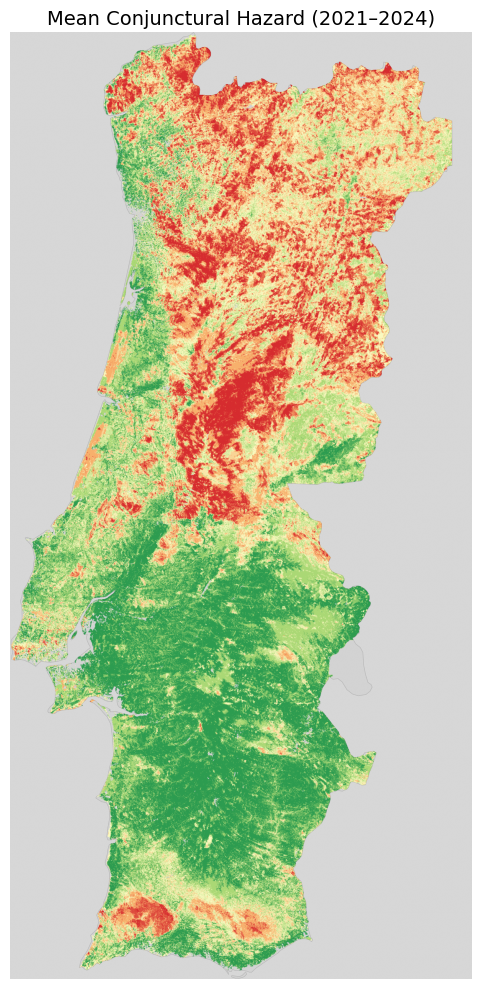

In [ ]:
colors_ramp = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]
cmap_hazard = LinearSegmentedColormap.from_list("hazard", colors_ramp)
cmap_hazard.set_bad(color="lightgrey")

hazard_display = np.where(port_mask, hazard_mean, np.nan)

fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5, zorder=1)
show(hazard_display, transform=ref_transform, ax=ax, cmap=cmap_hazard, zorder=2, alpha=0.9)
ax.set_title("Mean Conjunctural Hazard (2021–2024)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/mean_hazard.png", dpi=150)
plt.show()

### 3.6 Vegetation Index
We plot the vegetation density index across mainland Portugal. Higher 
values indicate denser vegetation and greater fuel availability for fires.

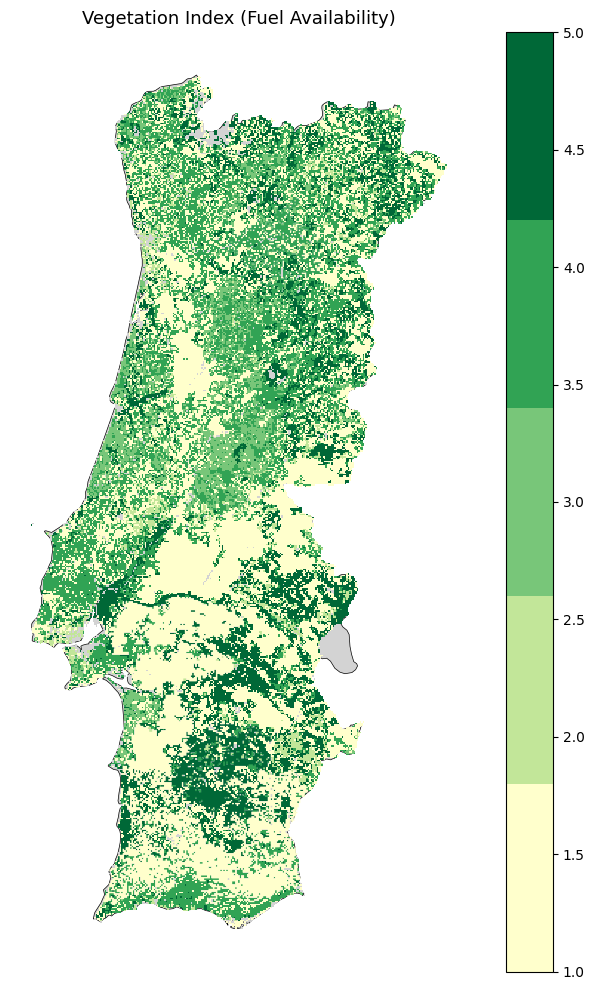

In [ ]:
colors_veg = ["#ffffcc", "#c2e699", "#78c679", "#31a354", "#006837"]
cmap_veg = LinearSegmentedColormap.from_list("veg", colors_veg, N=5)

fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
vegetation.plot(ax=ax, column="iqv_num", cmap=cmap_veg,
                legend=True, missing_kwds={"color": "lightgrey"})
ax.set_title("Vegetation Index (Fuel Availability)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/vegetation_index.png", dpi=150)
plt.show()

### 3.7 Aridity Index
We plot the aridity index across mainland Portugal. Higher values indicate 
drier conditions which increase fuel desiccation and fire susceptibility.

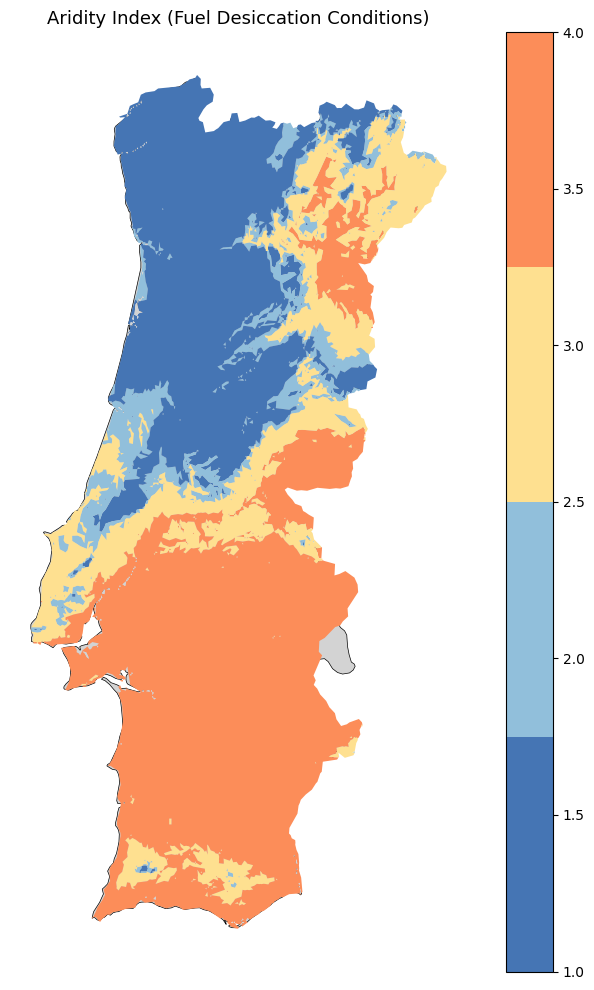

In [ ]:
colors_arid = ["#4575b4", "#91bfdb", "#fee090", "#fc8d59"]
cmap_arid = LinearSegmentedColormap.from_list("arid", colors_arid, N=4)

fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
aridity.plot(ax=ax, column="indaride_num", cmap=cmap_arid,
             legend=True, missing_kwds={"color": "lightgrey"})
ax.set_title("Aridity Index (Fuel Desiccation Conditions)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/aridity_index.png", dpi=150)
plt.show()

### 3.8 Critical Fire Locations
We plot the structurally fire-prone locations across mainland Portugal. 
These are areas characterised by high fuel continuity, difficult access 
and poor forest management that represent persistent territorial risk 
independent of annual climate conditions.

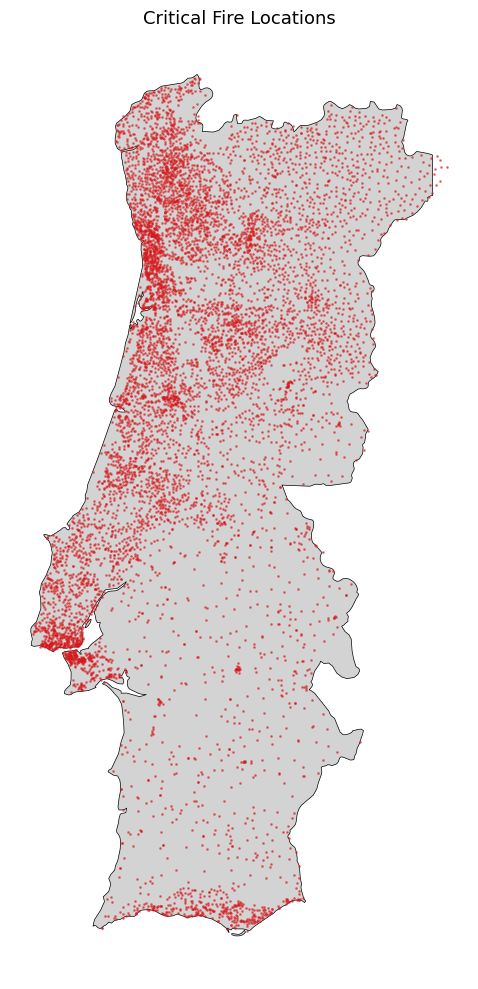

In [ ]:
fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
critical_locations.plot(ax=ax, color="#d7191c", markersize=1, alpha=0.5)
ax.set_title("Critical Fire Locations", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/critical_locations.png", dpi=150)
plt.show()

### 3.9 Primary Fuel Management Network
We plot the primary fuel management network — the prevention infrastructure 
designed to slow fire spread by creating fuel breaks across the territory.

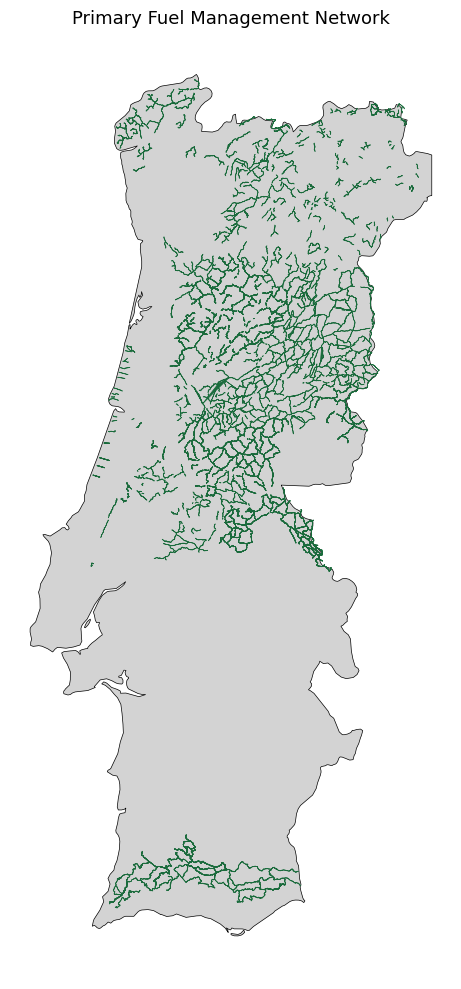

In [ ]:
fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
fuel_network.plot(ax=ax, color="#1a6b3c", edgecolor="#1a6b3c", linewidth=0.5, alpha=1)
ax.set_title("Primary Fuel Management Network", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/fuel_network.png", dpi=150)
plt.show()

### 3.10 Classify and Visualise the Wildfire Risk Map
We classify the continuous risk values into five equal interval categories 
and plot the final national wildfire risk map.

Category counts:
  Class 1 : 1,297,235 pixels (50.0%)
  Class 2 : 699,722 pixels (27.0%)
  Class 3 : 528,068 pixels (20.4%)
  Class 4 : 63,447 pixels (2.4%)
  Class 5 : 5,778 pixels (0.2%)


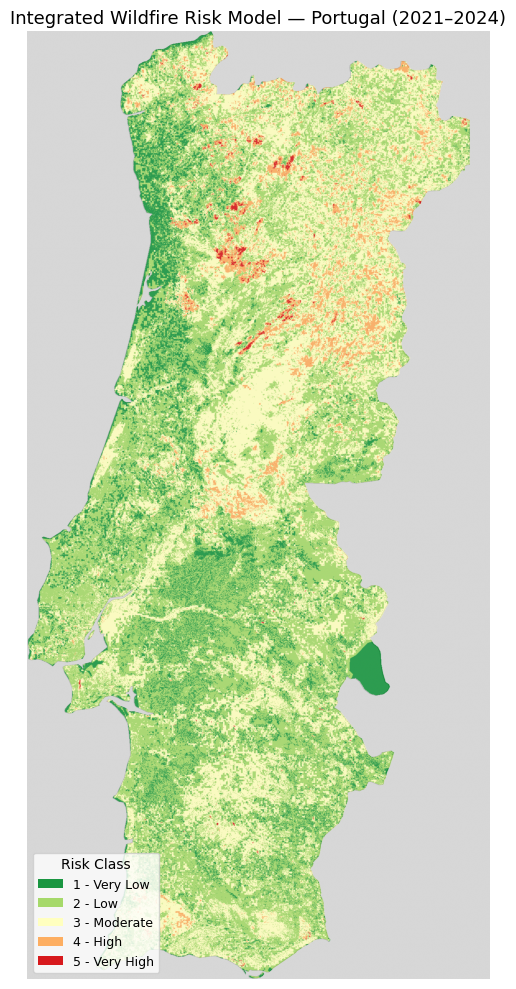

In [ ]:
# ── Define the colour map for the 5-class risk scale ─────────
# Green (low risk) -> yellow -> red (high risk) — a standard
# traffic-light scheme familiar to non-specialist readers.
colors_risk = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]
cmap_risk   = LinearSegmentedColormap.from_list("risk", colors_risk, N=5)
cmap_risk.set_bad(color="lightgrey")  # NaN pixels (outside Portugal) -> grey

legend_elements = [
    Patch(facecolor="#1a9641", label="1 - Very Low"),
    Patch(facecolor="#a6d96a", label="2 - Low"),
    Patch(facecolor="#ffffbf", label="3 - Moderate"),
    Patch(facecolor="#fdae61", label="4 - High"),
    Patch(facecolor="#d7191c", label="5 - Very High"),
]

# ── Equal-interval classification into 5 classes ─────────────
# The continuous risk values (~1 to ~5) are divided into five
# equal-width bins.  np.ceil rounds up so that value = risk_min
# maps to class 1 and value = risk_max maps to class 5.
# np.clip ensures floating-point rounding never produces class 0 or 6.
risk_min  = np.nanmin(risk_model)
risk_max  = np.nanmax(risk_model)
interval  = (risk_max - risk_min) / 5  # width of each class bin

risk_classified = np.where(
    ~np.isnan(risk_model),
    np.clip(np.ceil((risk_model - risk_min) / interval), 1, 5),
    np.nan
)

# Print the pixel count and percentage in each risk class so we can
# spot if the classification is heavily skewed toward one class.
print("Category counts:")
total = np.sum(~np.isnan(risk_classified))
for cat in [1, 2, 3, 4, 5]:
    count = np.sum(risk_classified == cat)
    print(f"  Class {int(cat)} : {count:,} pixels ({count/total*100:.1f}%)")

# ── Clip the risk map to the Portugal mainland boundary ───────
# Pixels outside mainland Portugal are set to NaN so they render
# as grey on the map (not as meaningless coloured values).
from rasterio.features import geometry_mask
port_mask = geometry_mask(
    portugal_geom,
    out_shape=ref_shape,
    transform=ref_transform,
    invert=True   # True = inside Portugal
)
risk_display = np.where(port_mask, risk_classified, np.nan)

# ── Plot the final integrated risk map ───────────────────────
fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5, zorder=1)
show(risk_display, transform=ref_transform, ax=ax, cmap=cmap_risk,
     vmin=1, vmax=5, zorder=2, alpha=0.9)
ax.legend(handles=legend_elements, loc="lower left", fontsize=9, title="Risk Class")
ax.set_title("Integrated Wildfire Risk Model -- Portugal (2021-2024)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/wildfire_risk_map.png", dpi=150)
plt.show()


## 4. Coverage Gap Analysis
### 4.1 Extract High Risk Zones
As the research question focuses on how well the fuel management network 
covers the highest risk areas, we extract only the cells classified as 
class 4 (High) and class 5 (Very High) risk. These areas form the basis 
of all subsequent coverage analysis.

Area by risk class:
  Class 1: 81,077.2 km2
  Class 2: 43,732.6 km2
  Class 3: 33,004.2 km2
  Class 4: 3,965.4 km2
  Class 5: 361.1 km2

Total high risk area (class 4+5): 4,326.6 km2


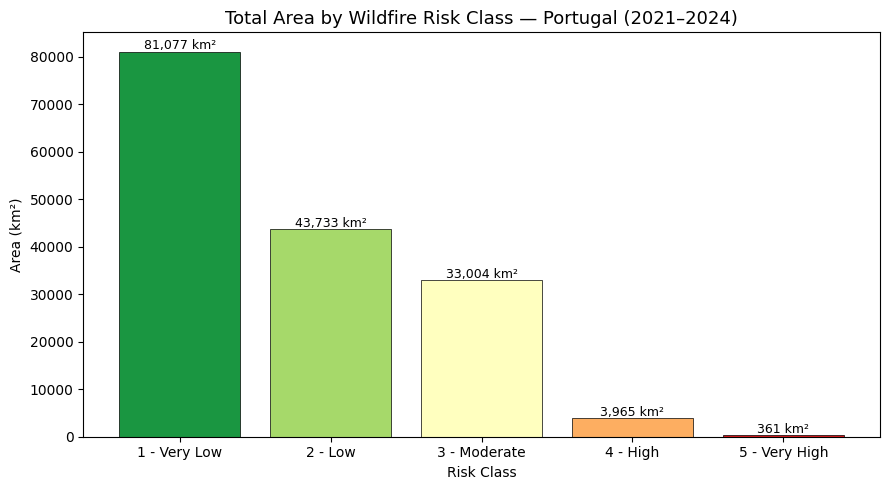

In [ ]:
# ── Extract pixels classified as High (4) or Very High (5) risk ─
# These two classes form the priority territory for the coverage
# gap analysis.  We focus on them because they represent the areas
# where a fire is most likely to occur and cause significant damage.
high_risk_mask = (risk_classified >= 4) & (~np.isnan(risk_classified))

# ── Calculate the land area in each risk class ───────────────
# Each pixel covers 250 m x 250 m = 62,500 m2 = 0.0625 km2.
# Multiplying the pixel count by this area gives km2.
pixel_area_km2 = (250 * 250) / 1e6   # = 0.0625 km2 per pixel

print("Area by risk class:")
total_valid = 0
for cat in [1, 2, 3, 4, 5]:
    count = np.sum(risk_classified == cat)
    area  = count * pixel_area_km2
    total_valid += count
    print(f"  Class {int(cat)}: {area:,.1f} km2")

high_risk_area = np.sum(high_risk_mask) * pixel_area_km2
print(f"\nTotal high risk area (class 4+5): {high_risk_area:,.1f} km2")

# ── Bar chart: area distribution across risk classes ─────────
categories = [1, 2, 3, 4, 5]
labels     = ["1 - Very Low", "2 - Low", "3 - Moderate", "4 - High", "5 - Very High"]
areas      = [np.sum(risk_classified == cat) * pixel_area_km2 for cat in categories]
bar_colors = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, areas, color=bar_colors, edgecolor="black", linewidth=0.5)

# Add exact area labels above each bar
for bar, area in zip(bars, areas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{area:,.0f} km2", ha="center", fontsize=9)

ax.set_title("Total Area by Wildfire Risk Class -- Portugal (2021-2024)", fontsize=13)
ax.set_xlabel("Risk Class")
ax.set_ylabel("Area (km2)")
plt.tight_layout()
plt.savefig("../outputs/area_by_risk_class.png", dpi=150)
plt.show()


### 4.2 Create Buffer Around Fuel Management Network
To evaluate whether a high risk area is covered by prevention infrastructure, 
we create buffer zones around the primary fuel management network at three 
distances: 500m, 1km and 2km. If a high risk area falls within the buffer 
it is considered covered. We test three distances to assess the sensitivity 
of results to the buffer size choice.

In [ ]:
from rasterio.features import rasterize
from shapely.geometry import mapping

# ── Convert the fuel management network (lines) to a raster ──
# The network is a vector dataset of lines (fuel breaks, cleared
# corridors).  We burn it into our reference grid so that every
# pixel that a fuel break line passes through gets value 1, and
# all other pixels get value 0.  This binary raster is the
# starting point for the buffer analysis in the next cell.
fuel_raster = rasterize(
    [(geom, 1) for geom in fuel_network.geometry if geom is not None],
    out_shape=ref_shape,
    transform=ref_transform,
    fill=0,        # background value = 0 (no fuel management infrastructure)
    dtype="uint8"  # 8-bit unsigned integer is sufficient for 0/1 values
)

print("Fuel network rasterised:", fuel_raster.shape)
print("Fuel pixels:", np.sum(fuel_raster == 1))  # how many pixels are on a fuel break


Fuel network rasterised: (2306, 1125)
Fuel pixels: 19000


In [ ]:
from scipy.ndimage import binary_dilation

# ── Create proximity buffers around the fuel management network ──
# A "buffer" is the zone within a given distance of the network.
# If a high-risk pixel falls inside the buffer, we consider it
# "covered" by the prevention infrastructure.
#
# binary_dilation expands a True/False mask outward by the specified
# number of pixels (iterations).
# At 250 m resolution:
#   2 iterations x 250 m/pixel = 500 m buffer
#   4 iterations x 250 m/pixel = 1,000 m (1 km) buffer
#   8 iterations x 250 m/pixel = 2,000 m (2 km) buffer
#
# WHY TEST THREE DISTANCES?
# There is no universally agreed effective radius for a fuel break.
# By testing 500 m, 1 km and 2 km we show how sensitive the
# coverage estimates are to this assumption.  The 1 km buffer is
# used as the primary distance in the municipal breakdown.

fuel_bool = fuel_raster == 1  # convert to boolean True/False array

buffer_500_raster  = binary_dilation(fuel_bool, iterations=2)   # 500 m
buffer_1000_raster = binary_dilation(fuel_bool, iterations=4)   # 1 km
buffer_2000_raster = binary_dilation(fuel_bool, iterations=8)   # 2 km

print("500m buffer pixels:",  np.sum(buffer_500_raster))
print("1km buffer pixels:",   np.sum(buffer_1000_raster))
print("2km buffer pixels:",   np.sum(buffer_2000_raster))


500m buffer pixels: 122930
1km buffer pixels: 227568
2km buffer pixels: 394336


### 4.3 Calculate National Coverage Statistics
We calculate what proportion of the high risk area (class 4+5) falls 
within each buffer distance of the primary fuel management network. 
This directly answers the first part of our research question: how 
effectively does the infrastructure cover high risk zones?

In [ ]:
# ── Calculate what fraction of high-risk land is covered ────
# For each buffer distance we count:
#   covered   = pixels that are BOTH high risk AND inside the buffer
#   uncovered = high risk pixels that fall OUTSIDE the buffer
#   coverage  = covered / total high risk x 100  (percentage)
#   gap       = uncovered / total high risk x 100 (the "prevention gap")

high_risk_mask   = (risk_classified >= 4) & (~np.isnan(risk_classified))
total_high_risk  = np.sum(high_risk_mask)
pixel_area_km2   = (250 * 250) / 1e6   # 0.0625 km2 per pixel

results = []
for name, buf in [("500m",  buffer_500_raster),
                  ("1km",   buffer_1000_raster),
                  ("2km",   buffer_2000_raster)]:

    # Logical AND: pixel must be high risk AND inside the buffer
    covered    = np.sum(high_risk_mask & buf)
    uncovered  = total_high_risk - covered
    coverage_pct = covered   / total_high_risk * 100
    gap_pct      = uncovered / total_high_risk * 100

    results.append({
        "Buffer":                  name,
        "Total High Risk (km2)":   total_high_risk * pixel_area_km2,
        "Covered (km2)":           covered         * pixel_area_km2,
        "Uncovered (km2)":         uncovered       * pixel_area_km2,
        "Coverage (%)":            round(coverage_pct, 1),
        "Gap (%)":                 round(gap_pct, 1)
    })

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


Buffer  Total High Risk (km²)  Covered (km²)  Uncovered (km²)  Coverage (%)  Gap (%)
  500m              4326.5625       940.0625        3386.5000          21.7     78.3
   1km              4326.5625      1670.7500        2655.8125          38.6     61.4
   2km              4326.5625      2660.5000        1666.0625          61.5     38.5


### 4.4 Visualise National Coverage — Stacked Bar Chart
We visualise the proportion of high risk area covered vs uncovered 
for each buffer distance.

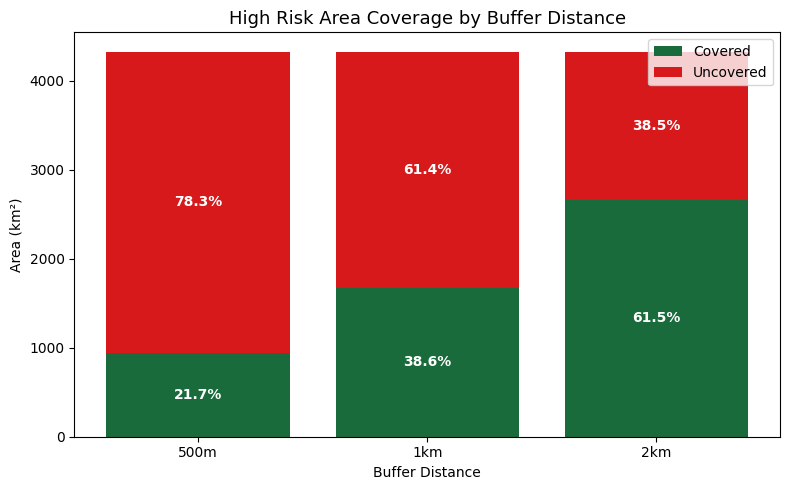

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

buffers = ["500m", "1km", "2km"]
covered = [940.06, 1670.75, 2660.50]
uncovered = [3386.50, 2655.81, 1666.06]

ax.bar(buffers, covered, color="#1a6b3c", label="Covered")
ax.bar(buffers, uncovered, bottom=covered, color="#d7191c", label="Uncovered")

for i, (c, u) in enumerate(zip(covered, uncovered)):
    total = c + u
    ax.text(i, c/2, f"{c/total*100:.1f}%", ha="center", va="center", 
            color="white", fontsize=10, fontweight="bold")
    ax.text(i, c + u/2, f"{u/total*100:.1f}%", ha="center", va="center",
            color="white", fontsize=10, fontweight="bold")

ax.set_title("High Risk Area Coverage by Buffer Distance", fontsize=13)
ax.set_xlabel("Buffer Distance")
ax.set_ylabel("Area (km²)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../outputs/national_coverage_stacked.png", dpi=150)
plt.show()

### 4.5 Municipal Level Coverage Analysis
We calculate coverage statistics for each municipality using the 1km 
buffer as the primary analysis distance. For each municipality we compute 
the total high risk area, the covered portion, the uncovered portion and 
the gap ratio. This allows us to identify which municipalities have the 
greatest unmet prevention needs.

In [ ]:
from rasterio.features import rasterize
import geopandas as gpd

# ── Loop over every municipality and compute coverage statistics ──
# For each of the 308 municipalities we:
#   1. Rasterise the municipality boundary -> a pixel mask (True inside)
#   2. Count high-risk pixels within the municipality
#   3. Count covered pixels (high risk AND within 1 km of fuel network)
#   4. Derive coverage %, gap %, and areas in km2
#
# NOTE: We use the 1 km buffer as the primary distance for municipal
# analysis.  This is a reasonable operational radius for a fuel break
# to effectively slow fire spread toward a community.

muni = municipalities.copy()
municipal_stats = []

for idx, row in muni.iterrows():
    geom = row.geometry
    name = row["NAME"]

    # Burn this single municipality boundary into a boolean pixel mask
    muni_mask = rasterize(
        [(geom, 1)],
        out_shape=ref_shape,
        transform=ref_transform,
        fill=0,
        dtype="uint8"
    ) == 1  # convert to boolean True/False

    # Count pixels in three overlapping categories:
    hr_pixels        = np.sum(high_risk_mask & muni_mask)   # high risk in municipality
    covered_pixels   = np.sum(high_risk_mask & muni_mask & buffer_1000_raster)  # covered
    uncovered_pixels = hr_pixels - covered_pixels           # uncovered = the gap

    # Percentages (NaN if municipality has no high-risk pixels at all)
    coverage_pct = (covered_pixels   / hr_pixels * 100) if hr_pixels > 0 else np.nan
    gap_pct      = (uncovered_pixels / hr_pixels * 100) if hr_pixels > 0 else np.nan

    municipal_stats.append({
        "Municipality":         name,
        "High Risk Area (km2)": round(hr_pixels        * pixel_area_km2, 2),
        "Covered (km2)":        round(covered_pixels   * pixel_area_km2, 2),
        "Uncovered (km2)":      round(uncovered_pixels * pixel_area_km2, 2),
        "Coverage (%)":         round(coverage_pct, 1),
        "Gap (%)":              round(gap_pct, 1)
    })

municipal_df = pd.DataFrame(municipal_stats)
# Sort by gap percentage descending to surface the worst-covered municipalities first
municipal_df = municipal_df.sort_values("Gap (%)", ascending=False)
print(municipal_df.head(10).to_string(index=False))


        Municipality  High Risk Area (km²)  Covered (km²)  Uncovered (km²)  Coverage (%)  Gap (%)
             Setúbal                  0.44            0.0             0.44           0.0    100.0
       Vila Do Bispo                  2.50            0.0             2.50           0.0    100.0
            Sesimbra                  3.88            0.0             3.88           0.0    100.0
               Moura                  1.38            0.0             1.38           0.0    100.0
               Lagoa                  0.12            0.0             0.12           0.0    100.0
              Mourão                  0.75            0.0             0.75           0.0    100.0
Ferreira Do Alentejo                  0.56            0.0             0.56           0.0    100.0
           Albufeira                  0.06            0.0             0.06           0.0    100.0
                Faro                  0.81            0.0             0.81           0.0    100.0
               Olhão

In [ ]:
municipal_df = municipal_df.sort_values("Uncovered (km²)", ascending=False)

# Filter out municipalities with very small high risk area (less than 1 km²)
municipal_significant = municipal_df[municipal_df["High Risk Area (km²)"] >= 1.0]

print("Top 10 municipalities by uncovered high risk area:")
print(municipal_significant.head(10).to_string(index=False))

Top 10 municipalities by uncovered high risk area:
        Municipality  High Risk Area (km²)  Covered (km²)  Uncovered (km²)  Coverage (%)  Gap (%)
        Castro Daire                153.31          68.44            84.88          44.6     55.4
              Guarda                193.69         110.69            83.00          57.1     42.9
   Torre De Moncorvo                 95.44          17.06            78.38          17.9     82.1
          Montalegre                102.56          27.00            75.56          26.3     73.7
              Pinhel                108.50          42.81            65.69          39.5     60.5
            Bragança                100.06          35.12            64.94          35.1     64.9
Vila Nova De Foz Côa                 77.88          18.69            59.19          24.0     76.0
               Mação                118.06          59.06            59.00          50.0     50.0
    São Pedro Do Sul                112.12          56.88          

### 4.6 Visualise Municipal Coverage Gaps
We map the gap ratio per municipality and show the top 10 municipalities 
with the largest uncovered high risk areas to identify priority zones 
for prevention investment.

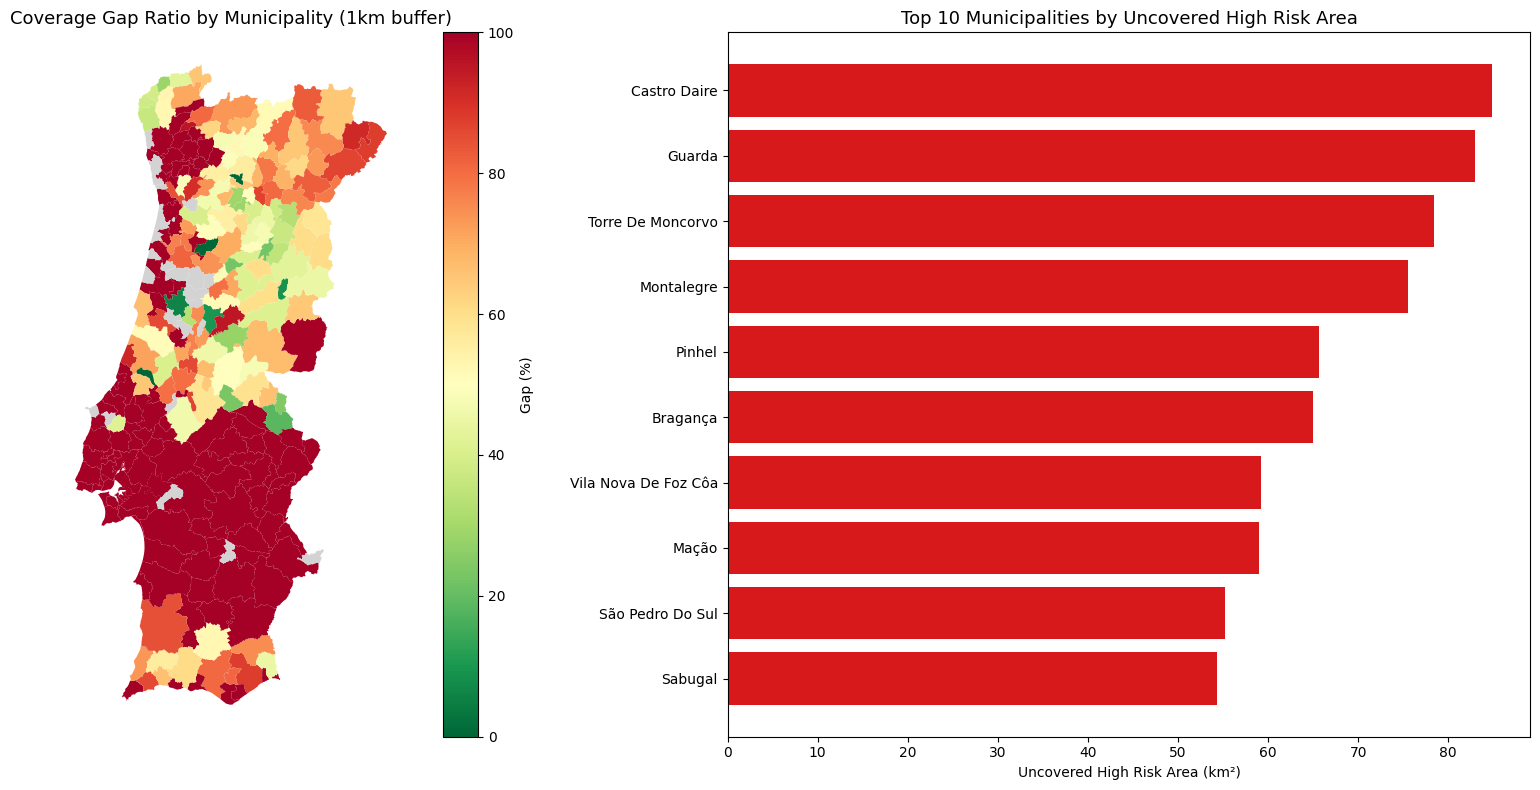

In [ ]:
# Join stats back to municipality geodataframe
municipal_geo = municipalities.merge(municipal_df, left_on="NAME", right_on="Municipality", how="left")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Map of gap ratio
municipal_geo.plot(ax=axes[0], column="Gap (%)", cmap="RdYlGn_r",
                   legend=True, missing_kwds={"color": "lightgrey"},
                   legend_kwds={"label": "Gap (%)"})
axes[0].set_title("Coverage Gap Ratio by Municipality (1km buffer)", fontsize=13)
axes[0].set_axis_off()

# Top 10 bar chart by uncovered area
top10 = municipal_significant.head(10)
axes[1].barh(top10["Municipality"], top10["Uncovered (km²)"], color="#d7191c")
axes[1].set_title("Top 10 Municipalities by Uncovered High Risk Area", fontsize=13)
axes[1].set_xlabel("Uncovered High Risk Area (km²)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/municipal_coverage_gaps.png", dpi=150)
plt.show()

### 4.7 Load Social Vulnerability Data
We use the INE 2023 Purchasing Power Index (PPC) per municipality as 
our social vulnerability indicator. Lower purchasing power indicates 
higher economic vulnerability. The data comes from INE's municipal 
purchasing power study (Estudo sobre o Poder de Compra Concelhio, 2023).

In [ ]:
vuln_df = pd.read_csv("../data/raw/social_vulnerability/QD5.csv", 
                       encoding="latin1", sep=";", skiprows=3, header=None)
vuln_df.columns = ["Municipality", "IpC", "PPC", "FDR"]

# Convert to float
vuln_df["IpC"] = pd.to_numeric(vuln_df["IpC"].str.replace(",", "."), errors="coerce")
vuln_df["PPC"] = pd.to_numeric(vuln_df["PPC"].str.replace(",", "."), errors="coerce")
vuln_df["FDR"] = pd.to_numeric(vuln_df["FDR"].str.replace(",", "."), errors="coerce")

# Drop NaN rows
vuln_df = vuln_df.dropna(subset=["PPC"])
vuln_df["Municipality"] = vuln_df["Municipality"].str.strip()

# Keep only actual municipalities by matching with shapefile names
muni_names = municipalities["NAME"].str.strip().tolist()
vuln_muni = vuln_df[vuln_df["Municipality"].isin(muni_names)].copy()

print(f"Matched municipalities: {len(vuln_muni)} out of {len(muni_names)}")
print(vuln_muni.head(10))

Matched municipalities: 193 out of 281
   Municipality     IpC    PPC    FDR
5       Caminha   82.12  0.127  0.944
6       Melgaço   64.90  0.046  0.927
7        Monção   75.84  0.129  0.501
11      Valença   84.67  0.113  0.556
15       Amares   75.17  0.138 -0.040
16     Barcelos   82.15  0.903 -0.474
17        Braga  105.49  1.999 -0.525
18    Esposende   88.00  0.307  0.076
20   Vila Verde   75.64  0.342 -0.138
23         Fafe   76.90  0.351 -0.189


In [ ]:
matched_names = vuln_muni["Municipality"].tolist()
unmatched = [name for name in muni_names if name not in matched_names]
print(f"Unmatched municipalities ({len(unmatched)}):")
for name in sorted(unmatched)[:20]:
    print(f"  '{name}'")

Unmatched municipalities (87):
  'Agueda'
  'Aguiar Da Beira'
  'Albergaria-A-Velha'
  'Alcacér Do Sal'
  'Alfândega Da Fé'
  'Alter Do Chão'
  'Arcos De Valdevez'
  'Arruda Dos Vinhos'
  'Cabeceiras De Basto'
  'Caldas Da Rainha'
  'Carrazeda De Ansiães'
  'Carregal Do Sal'
  'Castanheira De Pêra'
  'Castelo De Paiva'
  'Castelo De Vide'
  'Celorico Da Beira'
  'Celorico De Basto'
  'Condeixa-A-Nova'
  'Ferreira Do Alentejo'
  'Ferreira Do Zêzere'


In [ ]:
# ── Normalise municipality names for robust text matching ────
# The INE CSV and the shapefile may spell the same municipality
# differently (e.g. accents, capitalisation, spacing).  We strip
# all diacritics and convert to lowercase so that "Evora" and
# "evora" are treated as identical strings.
import unicodedata

def normalise_name(name):
    """
    Lowercase a municipality name and remove all accent marks
    (diacritics) so it can be matched against a differently-
    encoded version of the same name.

    Example: "Evora" -> "evora", "Sao Joao" -> "sao joao"
    """
    name = name.strip().lower()
    # NFKD decomposition separates each accented character into its
    # base letter + a combining accent codepoint
    name = unicodedata.normalize("NFKD", name)
    # Remove all combining characters (the accent marks themselves)
    name = "".join(c for c in name if not unicodedata.combining(c))
    return name

# Apply normalisation to both datasets, then match on the clean version
vuln_df["name_norm"]  = vuln_df["Municipality"].apply(normalise_name)
# Build a lookup dictionary: normalised name -> original shapefile name
muni_norm = {normalise_name(n): n for n in muni_names}

# Map each vulnerability row to the canonical shapefile name
vuln_df["matched_name"] = vuln_df["name_norm"].map(muni_norm)

# Keep only rows that successfully matched a shapefile municipality
# and have a valid PPC (purchasing power) value
vuln_muni = vuln_df.dropna(subset=["matched_name", "PPC"]).copy()

print(f"Matched municipalities: {len(vuln_muni)} out of {len(muni_names)}")
print(vuln_muni.head(5))


Matched municipalities: 278 out of 281
        Municipality    IpC    PPC    FDR          name_norm  \
4  Arcos de Valdevez  72.53  0.142  0.386  arcos de valdevez   
5            Caminha  82.12  0.127  0.944            caminha   
6            Melgaço  64.90  0.046  0.927            melgaco   
7             Monção  75.84  0.129  0.501             moncao   
8   Paredes de Coura  69.78  0.057 -0.141   paredes de coura   

        matched_name  
4  Arcos De Valdevez  
5            Caminha  
6            Melgaço  
7             Monção  
8   Paredes De Coura  


### 4.8 Create Social Vulnerability Score
We use the per capita income index (IpC) from INE 2023 as our vulnerability 
indicator. Portugal's national average is 100. Municipalities below 100 have 
lower than average purchasing power and are considered more vulnerable.
We invert and normalise the index to a 0-1 scale where 1 = most vulnerable.

In [ ]:
# ── Invert and normalise IpC to a 0-1 vulnerability score ───
# IpC (Indice per capita) is Portugal's per capita income index,
# where 100 = the national average.
#   IpC > 100 -> above-average income -> lower vulnerability
#   IpC < 100 -> below-average income -> higher vulnerability
#
# We invert it so that the score is intuitive for our analysis:
#   0 = least vulnerable (highest income relative to national average)
#   1 = most vulnerable  (lowest income relative to national average)
#
# Inversion formula:
#   vulnerability = 1 - (IpC - min_IpC) / (max_IpC - min_IpC)
#
# This is standard min-max normalisation applied in inverse direction.

vuln_muni = vuln_muni.copy()
vuln_muni["vulnerability"] = 1 - (
    (vuln_muni["IpC"] - vuln_muni["IpC"].min()) /
    (vuln_muni["IpC"].max() - vuln_muni["IpC"].min())
)

# Join the vulnerability scores back to the municipality GeoDataFrame
# so we can map them spatially.  We match on the canonical shapefile
# name ("matched_name" in the vulnerability table, "NAME" in geo layer).
vuln_geo = municipalities.merge(
    vuln_muni[["matched_name", "IpC", "PPC", "vulnerability"]],
    left_on="NAME", right_on="matched_name", how="left"
)

print(f"Municipalities with vulnerability score: {vuln_geo['vulnerability'].notna().sum()}")
print(vuln_geo[["NAME", "IpC", "vulnerability"]].sort_values("vulnerability", ascending=False).head(10))


Municipalities with vulnerability score: 281
                         NAME    IpC  vulnerability
187                   Tabuaço  63.53       1.000000
274                 Penamacor  63.77       0.997963
117                   Vimioso  63.80       0.997708
118                   Vinhais  64.26       0.993804
264                     Baião  64.54       0.991428
266               Sernancelhe  64.72       0.989900
107                   Melgaço  64.90       0.988372
81                   Valpaços  64.93       0.988117
189  Santa Marta De Penaguião  65.00       0.987523
72          Celorico De Basto  65.08       0.986844


### 4.9 Visualise Social Vulnerability
We map the vulnerability score per municipality. Darker colours indicate 
higher vulnerability (lower per capita income relative to national average).

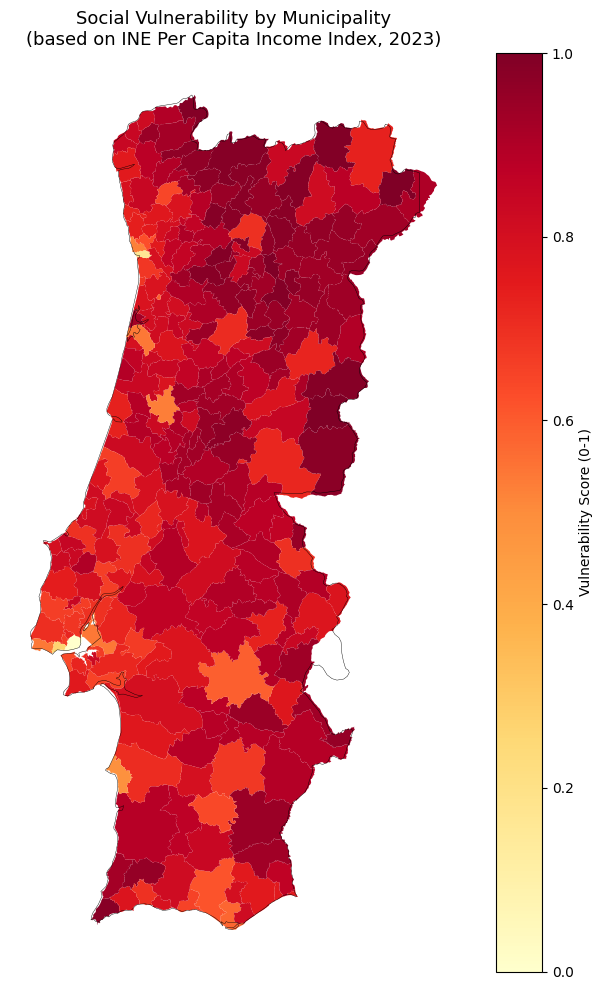

In [ ]:
fig, ax = plt.subplots(figsize=(8, 10))
vuln_geo.plot(ax=ax, column="vulnerability", cmap="YlOrRd",
              legend=True, missing_kwds={"color": "lightgrey"},
              legend_kwds={"label": "Vulnerability Score (0-1)"})
portugal_mainland.plot(ax=ax, color="none", edgecolor="black", linewidth=0.3)
ax.set_title("Social Vulnerability by Municipality\n(based on INE Per Capita Income Index, 2023)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/vulnerability_map.png", dpi=150)
plt.show()

## 5. Inequality Analysis
### 5.1 Combine Coverage Gaps and Vulnerability
We join the municipal coverage gap statistics with the vulnerability scores 
to test whether municipalities with higher social vulnerability also face 
greater gaps in wildfire prevention coverage — the core of our inequality argument.

In [ ]:
# Join municipal stats with vulnerability
analysis_df = municipal_geo.merge(
    vuln_geo[["NAME", "IpC", "vulnerability"]],
    on="NAME", how="left"
)

# Drop municipalities with no high risk area
analysis_df = analysis_df[analysis_df["High Risk Area (km²)"] > 0].copy()

print(f"Municipalities with high risk area: {len(analysis_df)}")
print(analysis_df[["NAME", "High Risk Area (km²)", "Gap (%)", "vulnerability"]].head(10))

Municipalities with high risk area: 272
            NAME  High Risk Area (km²)  Gap (%)  vulnerability
0        Setúbal                  0.44    100.0       0.650569
1  Vila Do Bispo                  2.50    100.0       0.980479
2       Sesimbra                  3.88    100.0       0.759803
3          Moura                  1.38    100.0       0.888304
4         Tavira                  9.50     87.5       0.754371
5          Loulé                  6.81     80.7       0.617128
6         Mourão                  0.75    100.0       0.932100
7          Lagos                  1.75     85.7       0.776269
8          Lagoa                  0.12    100.0       0.788236
9           Faro                  0.81    100.0       0.577661


### 5.2 Scatter Plot — Vulnerability vs Coverage Gap
The scatter plot directly answers our research question: are coverage gaps 
disproportionately concentrated in the most socially vulnerable municipalities? 
Each point represents one municipality. A positive trend would indicate 
that more vulnerable municipalities tend to have larger coverage gaps.

In [ ]:
from scipy import stats

# ── Prepare the scatter dataset ───────────────────────────────
# Drop rows missing either variable so the regression is valid.
scatter_df = analysis_df.dropna(subset=["Gap (%)", "vulnerability"])

# ── Scatter plot: vulnerability (x) vs gap (y) ───────────────
# Each dot is one municipality.
# Dot colour encodes total high-risk area: larger area -> darker orange/red.
# This lets us spot whether municipalities with large high-risk territories
# cluster in a specific part of the chart.
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    scatter_df["vulnerability"],    # x-axis: social vulnerability score 0-1
    scatter_df["Gap (%)"],          # y-axis: % of high-risk area not covered
    c=scatter_df["High Risk Area (km2)"],  # colour = size of high-risk territory
    cmap="YlOrRd",                  # yellow (small area) -> red (large area)
    alpha=0.7,                      # slight transparency to reveal overlaps
    edgecolors="black",
    linewidth=0.3,
    s=50                            # marker size in points squared
)

# ── Ordinary least-squares trend line ────────────────────────
# stats.linregress fits y = slope x + intercept and returns:
#   r = Pearson correlation coefficient (-1 to +1)
#   p = p-value: probability the trend is due to chance alone
# A p-value < 0.05 means the trend is statistically significant.
slope, intercept, r, p, se = stats.linregress(
    scatter_df["vulnerability"], scatter_df["Gap (%)"]
)
x_line = np.linspace(scatter_df["vulnerability"].min(), scatter_df["vulnerability"].max(), 100)
ax.plot(x_line, slope * x_line + intercept,
        color="black", linewidth=1.5, linestyle="--",
        label=f"Trend (r={r:.2f}, p={p:.3f})")

# ── Label the 5 most critical municipalities ─────────────────
# "Most critical" = largest absolute uncovered area (km2),
# regardless of the gap ratio.  These are the places where the
# prevention deficit is largest in absolute terms.
top5 = scatter_df.nlargest(5, "Uncovered (km2)")
for _, row in top5.iterrows():
    ax.annotate(row["NAME"], (row["vulnerability"], row["Gap (%)"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")

plt.colorbar(scatter, ax=ax, label="High Risk Area (km2)")
ax.set_xlabel("Vulnerability Score (0=least, 1=most vulnerable)", fontsize=11)
ax.set_ylabel("Coverage Gap (%)", fontsize=11)
ax.set_title("Social Vulnerability vs Wildfire Prevention Coverage Gap\nby Municipality", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../outputs/scatter_vulnerability_gap.png", dpi=150)
plt.show()

print(f"\nCorrelation: r={r:.3f}, p-value={p:.4f}")



KeyboardInterrupt



### 5.2 Interpretation of Scatter Plot Results
The scatter plot reveals a statistically significant negative correlation 
(r = -0.37, p < 0.001) between vulnerability and coverage gap. Contrary 
to what a simple inequality hypothesis would predict, more vulnerable 
municipalities do not systematically face larger coverage gaps. This is 
because the primary fuel management network is concentrated in the northern 
and central interior — precisely where both fire risk and vulnerability are 
highest — suggesting that network placement is broadly risk-informed.

However, this does not mean the situation is equitable. The municipalities 
with the largest absolute uncovered high risk areas (Castro Daire, Guarda, 
Torre de Moncorvo, Montalegre, Bragança) are all highly vulnerable interior 
municipalities. The relative coverage may be better than expected, but the 
sheer scale of unprotected territory in these areas — combined with their 
elderly, isolated and economically marginalised populations — represents a 
significant territorial inequality. A municipality with 80 km² of uncovered 
high risk area and a vulnerability score of 0.98 faces a very different 
challenge than a coastal municipality with 0.5 km² uncovered.

The inequality argument therefore shifts from "the network ignores vulnerable 
places" to "the network exists but is insufficient given the scale of risk 
and the limited capacity of vulnerable communities to self-protect."

In [ ]:
from scipy import stats

# Drop rows with missing values
scatter_df = analysis_df.dropna(subset=["Gap (%)", "vulnerability"])

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    scatter_df["vulnerability"],
    scatter_df["Gap (%)"],
    c=scatter_df["High Risk Area (km²)"],
    cmap="YlOrRd",
    alpha=0.7,
    edgecolors="black",
    linewidth=0.3,
    s=50
)

# Trend line
slope, intercept, r, p, se = stats.linregress(
    scatter_df["vulnerability"], scatter_df["Gap (%)"]
)
x_line = np.linspace(scatter_df["vulnerability"].min(), scatter_df["vulnerability"].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="black", linewidth=1.5, linestyle="--", label=f"Trend (r={r:.2f}, p={p:.3f})")

# Label top 5 most critical municipalities
top5 = scatter_df.nlargest(5, "Uncovered (km²)")
for _, row in top5.iterrows():
    ax.annotate(row["NAME"], (row["vulnerability"], row["Gap (%)"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")

plt.colorbar(scatter, ax=ax, label="High Risk Area (km²)")
ax.set_xlabel("Vulnerability Score (0=least, 1=most vulnerable)", fontsize=11)
ax.set_ylabel("Coverage Gap (%)", fontsize=11)
ax.set_title("Social Vulnerability vs Wildfire Prevention Coverage Gap\nby Municipality", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../outputs/scatter_vulnerability_gap.png", dpi=150)
plt.show()

print(f"\nCorrelation: r={r:.3f}, p-value={p:.4f}")


# Top 10 municipalities by uncovered high-risk area
# Ranks municipalities by total uncovered area and selects the top 10,
# combining coverage statistics with economic vulnerability scores
# for a direct comparison of prevention gaps and economic fragility
top10_table = analysis_df.dropna(subset=["Gap (%)", "vulnerability"])\
    .sort_values("Uncovered (km²)", ascending=False)\
    .head(10)[["NAME", "High Risk Area (km²)", "Coverage (%)", "Gap (%)", "vulnerability"]]\
    .rename(columns={"NAME": "Municipality", "vulnerability": "Vulnerability Score"})

print(top10_table.to_string(index=False))

NameError: name 'analysis_df' is not defined

### 5.3 Priority Classification
We classify each municipality into priority levels for policy intervention 
by combining their gap ratio and vulnerability score. Municipalities with 
both high coverage gaps and high vulnerability represent the most urgent 
cases for targeted prevention investment.

In [ ]:
# ── Classify each municipality by intervention priority ──────
# We combine two dimensions — coverage gap and social vulnerability —
# to identify where prevention investment is both most needed
# (high gap) and where communities have the least capacity to
# self-protect (high vulnerability).  An additional filter on
# high-risk area size ensures we focus on places where the
# absolute stakes are largest.
#
# Thresholds are set at the median of each dimension, splitting
# municipalities into above-median and below-median groups.

gap_threshold  = scatter_df["Gap (%)"].median()
vuln_threshold = scatter_df["vulnerability"].median()

print(f"Gap threshold (median): {gap_threshold:.1f}%")
print(f"Vulnerability threshold (median): {vuln_threshold:.3f}")

def assign_priority(row):
    """
    Assign a 5-level intervention priority based on gap, vulnerability
    and the size of the high-risk territory.

    Very High : above-median gap + above-median vulnerability
                + at least 10 km2 of high-risk area
                -> large territory, vulnerable population, poorly covered
    High      : above-median gap + above-median vulnerability (but <10 km2)
                -> vulnerable but smaller territory
    Medium    : above-median gap + below-median vulnerability
                -> coverage gap exists but community is more resilient
    Low-Medium: below-median gap + above-median vulnerability
                -> vulnerable community but relatively well covered
    Low       : below-median gap + below-median vulnerability
                -> relatively safe and resilient
    """
    high_gap  = row["Gap (%)"]               >= gap_threshold
    high_vuln = row["vulnerability"]         >= vuln_threshold
    high_risk = row["High Risk Area (km2)"]  >= 10  # at least 10 km2 of high-risk land

    if   high_gap and high_vuln and high_risk: return "Very High"
    elif high_gap and high_vuln:               return "High"
    elif high_gap and not high_vuln:           return "Medium"
    elif not high_gap and high_vuln:           return "Low-Medium"
    else:                                       return "Low"

scatter_df["Priority"] = scatter_df.apply(assign_priority, axis=1)

print("\nPriority distribution:")
print(scatter_df["Priority"].value_counts())


Gap threshold (median): 86.8%
Vulnerability threshold (median): 0.851

Priority distribution:
Priority
Medium        92
Low-Medium    92
Low           44
High          35
Very High      9
Name: count, dtype: int64


### 5.4 Priority Map
We map the priority classification to identify where targeted policy 
intervention is most urgently needed — municipalities combining high 
coverage gaps, high vulnerability and large high risk areas.

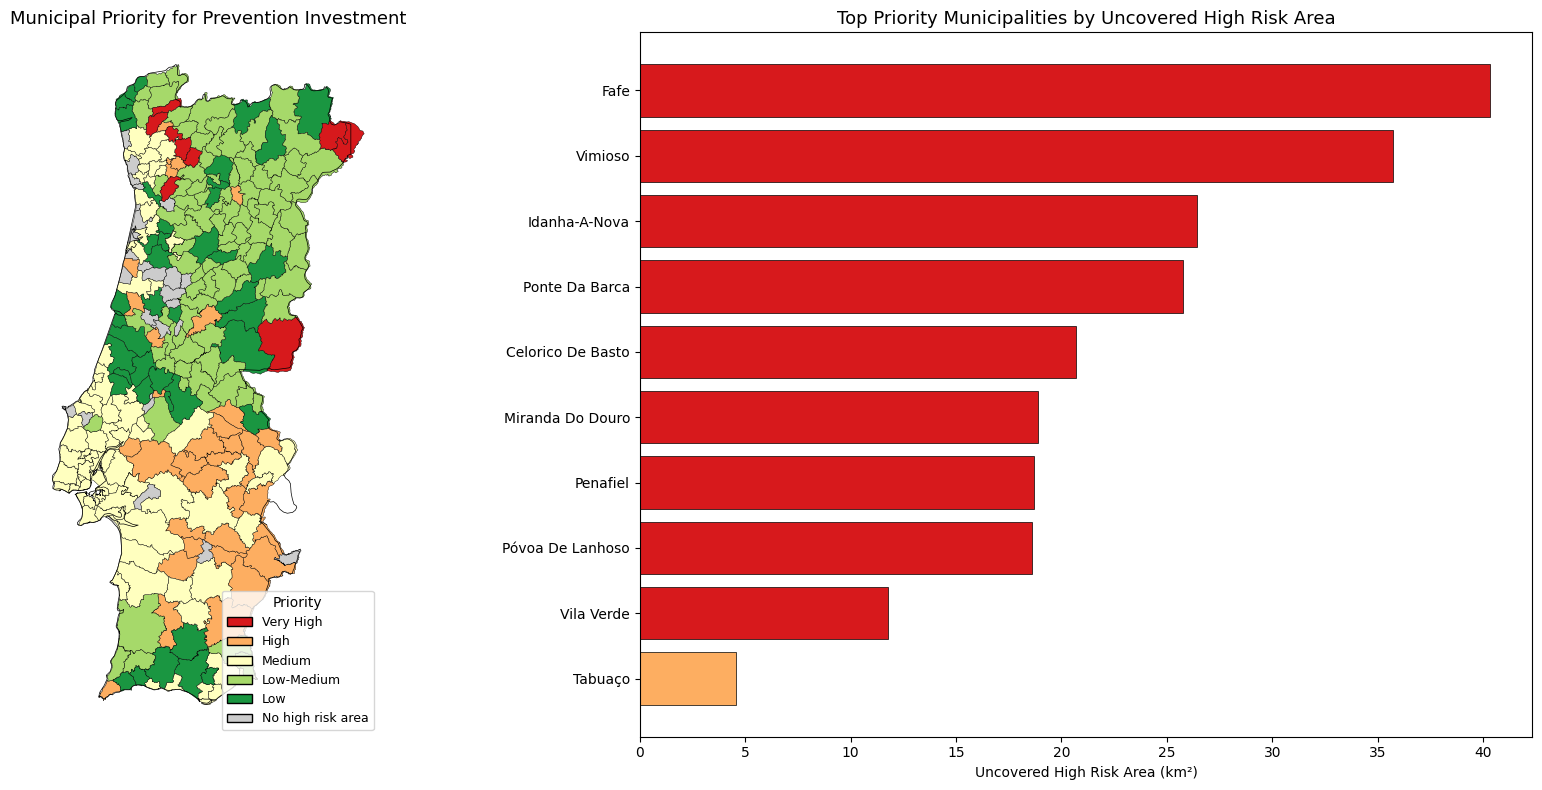

In [ ]:
# Join priority back to geodataframe
priority_geo = municipalities.merge(
    scatter_df[["NAME", "Priority", "Gap (%)", "vulnerability", "High Risk Area (km²)"]],
    on="NAME", how="left"
)

# Define colour mapping
priority_colors = {
    "Very High": "#d7191c",
    "High": "#fdae61",
    "Medium": "#ffffbf",
    "Low-Medium": "#a6d96a",
    "Low": "#1a9641"
}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Priority map
priority_geo["color"] = priority_geo["Priority"].map(priority_colors).fillna("#cccccc")
priority_geo.plot(ax=axes[0], color=priority_geo["color"], edgecolor="black", linewidth=0.3)
portugal_mainland.plot(ax=axes[0], color="none", edgecolor="black", linewidth=0.5)

legend_elements = [Patch(facecolor=c, edgecolor="black", label=p) 
                   for p, c in priority_colors.items()]
legend_elements.append(Patch(facecolor="#cccccc", edgecolor="black", label="No high risk area"))
axes[0].legend(handles=legend_elements, loc="lower right", 
               fontsize=9, title="Priority", bbox_to_anchor=(1.0, 0.0))
axes[0].set_title("Municipal Priority for Prevention Investment", fontsize=13)
axes[0].set_axis_off()

# Top priority bar chart
top_priority = scatter_df[scatter_df["Priority"].isin(["Very High", "High"])]\
    .sort_values("Uncovered (km²)", ascending=False).head(10)

colors_bar = [priority_colors[p] for p in top_priority["Priority"]]
axes[1].barh(top_priority["NAME"], top_priority["Uncovered (km²)"],
             color=colors_bar, edgecolor="black", linewidth=0.5)
axes[1].set_title("Top Priority Municipalities by Uncovered High Risk Area", fontsize=13)
axes[1].set_xlabel("Uncovered High Risk Area (km²)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/priority_map.png", dpi=150)
plt.show()

### 5.5 Correlation Heatmap
We compute a correlation matrix between the key municipal indicators: 
high risk area, coverage percentage, gap ratio and vulnerability score. 
This gives an overview of how these dimensions relate to each other.

In [ ]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])

0

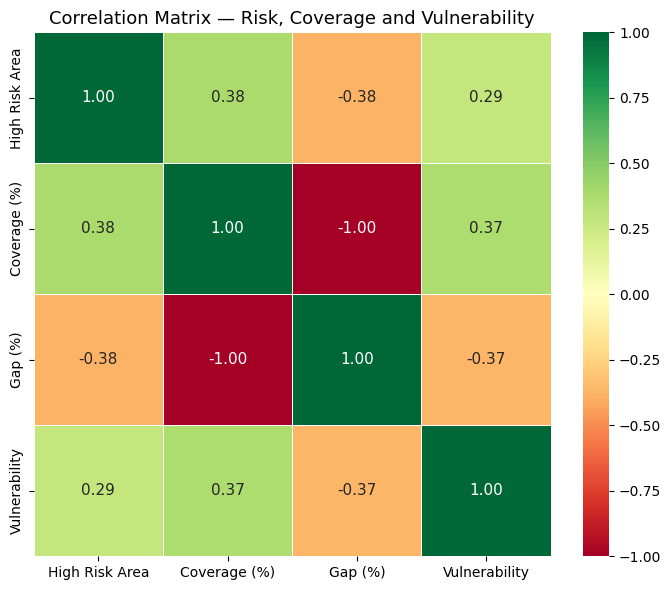

In [ ]:
import seaborn as sns

corr_df = scatter_df[["High Risk Area (km²)", "Coverage (%)", "Gap (%)", "vulnerability"]].copy()
corr_df.columns = ["High Risk Area", "Coverage (%)", "Gap (%)", "Vulnerability"]

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={"size": 11})
ax.set_title("Correlation Matrix — Risk, Coverage and Vulnerability", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", dpi=150)
plt.show()

### Interpretation of Correlation Heatmap
The correlation matrix confirms and extends the findings from the scatter plot:

- **Coverage (%) and Gap (%) show a perfect inverse correlation (-1.00)** — 
  this is expected since they are mathematical complements of each other.

- **High Risk Area and Coverage (%) show a moderate positive correlation (0.38)** — 
  municipalities with larger high risk areas tend to have better coverage. 
  This supports the idea that the fuel network was placed where fire risk is 
  highest, rather than randomly or based on other criteria.

- **Vulnerability and Coverage (%) show a moderate positive correlation (0.37)** — 
  more vulnerable municipalities tend to have slightly better coverage, 
  consistent with the scatter plot finding that the network broadly follows 
  risk patterns in the interior where vulnerability is also highest.

- **Vulnerability and Gap (%) show a moderate negative correlation (-0.37)** — 
  confirming that more vulnerable municipalities do not systematically face 
  larger gaps in relative terms.

Overall, the heatmap suggests that the primary fuel management network is 
broadly aligned with both fire risk and territorial vulnerability. However, 
as shown in the priority analysis, several highly vulnerable municipalities 
still have large absolute areas of uncovered high risk land, pointing to 
the need for targeted expansion of prevention infrastructure in these territories.